In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D , MaxPooling2D , Flatten , Dense , Dropout , BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator


2026-06-23 15:18:05.997313: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782227886.394270      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782227886.506959      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782227887.465333      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782227887.465381      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782227887.465384      57 computation_placer.cc:177] computation placer alr

In [5]:
base = '/kaggle/input/datasets/jonathanoheix/face-expression-recognition-dataset'
test = os.path.join(base,'images','validation')
train = os.path.join(base,'images','train')
classes = sorted(os.listdir(train))
print (classes)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


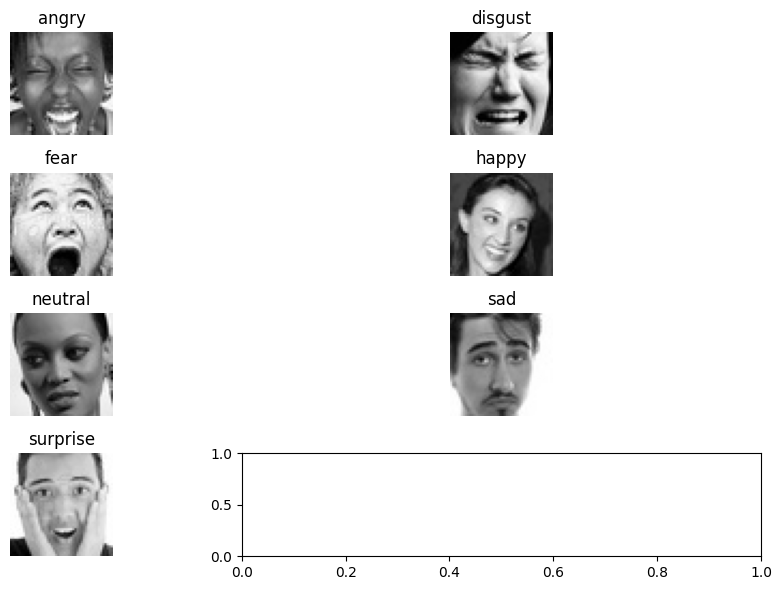

In [6]:
fig , axes = plt.subplots(4,2,figsize=(10,6))
for ax, cls in zip(axes.flat,classes):
    image_path = os.path.join(train,cls,os.listdir(os.path.join(train,cls))[0])
    image = cv2.imread(image_path,0)
    #image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    ax.imshow(image,cmap = 'gray')
    ax.set_title(cls)
    ax.axis('off')
  
plt.tight_layout()
plt.show()

In [7]:
ImgSize = 64
def load_data(directory):
    images = []
    labels = []
    for cls in classes:
        folder = os.path.join(directory,cls)
        for fname in os.listdir(folder):
            img = cv2.imread(os.path.join(folder,fname),0)
            if img is None:
                continue
            img = cv2.resize(img,(ImgSize,ImgSize))
           # img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
            images.append(img)
            labels.append(cls)
    return np.array(images),np.array(labels)
xtrain_raw,ytrain_raw = load_data(train)
xtest_raw,ytest_raw = load_data(test)
print(xtrain_raw.shape,xtest_raw.shape)

(28821, 64, 64) (7066, 64, 64)


In [9]:
xtrain = xtrain_raw/255
xtest = xtest_raw/255

le = LabelEncoder()
ytrain = to_categorical(le.fit_transform(ytrain_raw))
ytest = to_categorical(le.transform(ytest_raw))

print(le.classes_,'\n')
print(xtrain.shape,'\n',ytrain.shape)

['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad' 'surprise'] 

(28821, 64, 64) 
 (28821, 7)


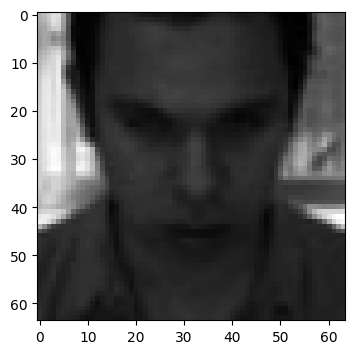

In [10]:
sample = xtrain[1]
fig, axes = plt.subplots(1,1,figsize=(14,4))
axes.imshow(sample,cmap = 'gray')
plt.show()

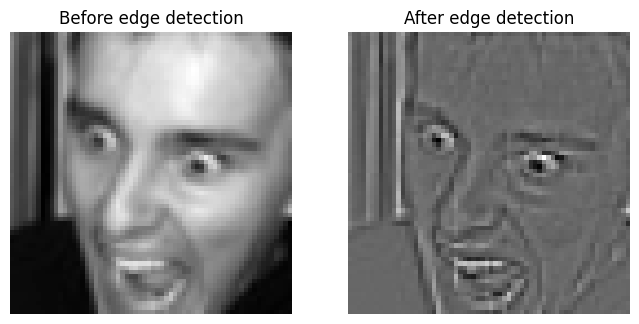

In [11]:
from scipy.ndimage import convolve
gray = xtrain[100]

edge_kernel = np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]])
cnvld = convolve(gray,edge_kernel)

fig,axes = plt.subplots(1,2,figsize = (8,4))
axes[0].imshow(gray,cmap='gray')
axes[0].set_title('Before edge detection')
axes[1].imshow(cnvld,cmap='gray')
axes[1].set_title('After edge detection')

for ax in axes:
    ax.axis('off')
plt.show() 


In [14]:
model = Sequential([
    Conv2D(32,(3,3),activation = 'relu',padding = 'same',input_shape = (ImgSize,ImgSize,1)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation = 'relu',padding = 'same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation = 'relu',padding = 'same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256,activation = 'relu'),
    Dropout(0.4),
    Dense(len(classes),activation = 'softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1782228363.989828      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782228363.995929      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,192,775 (8.36 MB)

 Trainable params: 2,192,327 (8.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [15]:
for layer in model.layers:
    if hasattr(layer,'output'):
        print(f"{layer.name:30s} output shape:{str(layer.output.shape)}")

conv2d                         output shape:(None, 64, 64, 32)
batch_normalization            output shape:(None, 64, 64, 32)
max_pooling2d                  output shape:(None, 32, 32, 32)
conv2d_1                       output shape:(None, 32, 32, 64)
batch_normalization_1          output shape:(None, 32, 32, 64)
max_pooling2d_1                output shape:(None, 16, 16, 64)
conv2d_2                       output shape:(None, 16, 16, 128)
batch_normalization_2          output shape:(None, 16, 16, 128)
max_pooling2d_2                output shape:(None, 8, 8, 128)
flatten                        output shape:(None, 8192)
dense                          output shape:(None, 256)
dropout                        output shape:(None, 256)
dense_1                        output shape:(None, 7)


IndexError: index 7 is out of bounds for axis 1 with size 7

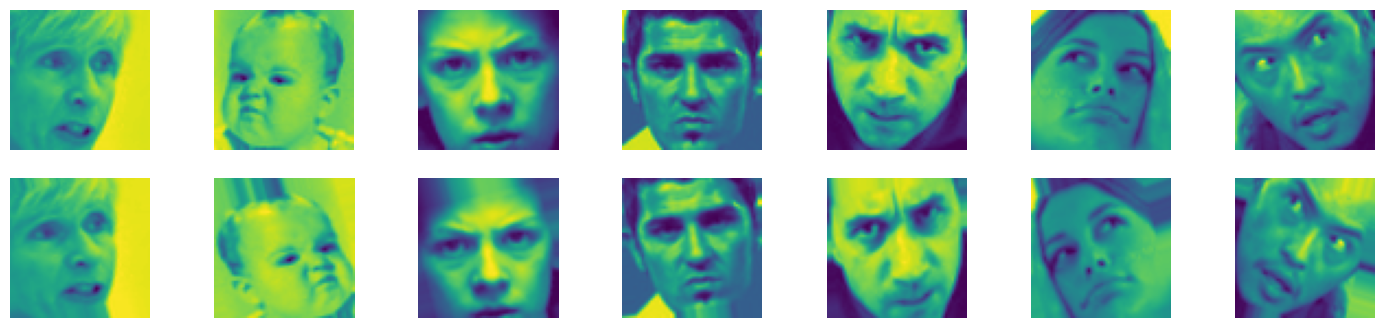

In [16]:
datagen =ImageDataGenerator(
    rotation_range = 20,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    horizontal_flip = True,
    zoom_range = 0.1
    
)

sb = xtrain[15:24].reshape(-1,64,64,1)
aug_iter = datagen.flow(sb,batch_size = 9,shuffle = False)
aug_batch = next(aug_iter)

fig, axes = plt.subplots(2,7,figsize = (18,4))

for i in range(9):
    axes[0,i].imshow(sb[i])
    axes[0,i].axis('off')
    axes[1,i].imshow(np.clip(aug_batch[i],0,1))
    axes[1,i].axis('off')

axes[0,0].set_ylabel("original",fontsize = 10)
axes[1,0].set_ylabel("augmented",fontsize = 10)
    
plt.tight_layout()
plt.show()

In [17]:
model.compile(optimizer = 'adam',loss = 'categorical_crossentropy',metrics =['accuracy'])

xtrain = xtrain.reshape(-1,64,64,1)
xtest  = xtest.reshape(-1,64,64,1)

history = model.fit( 
    datagen.flow(xtrain,ytrain,batch_size = 64),
    epochs = 20,
    validation_data = (xtest,ytest)
                   )

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1782228404.912631     144 service.cc:152] XLA service 0x7c45ac002c40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782228404.912675     144 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782228404.912679     144 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782228405.602115     144 cuda_dnn.cc:529] Loaded cuDNN version 91002


  5/451 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.1737 - loss: 7.4561

I0000 00:00:1782228410.959782     144 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


451/451 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.2321 - loss: 2.4493 - val_accuracy: 0.2719 - val_loss: 1.7905
Epoch 2/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.2668 - loss: 1.7718 - val_accuracy: 0.2963 - val_loss: 1.6834
Epoch 3/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.2945 - loss: 1.7053 - val_accuracy: 0.3674 - val_loss: 1.6171
Epoch 4/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.3180 - loss: 1.6458 - val_accuracy: 0.2305 - val_loss: 2.2297
Epoch 5/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.3528 - loss: 1.5851 - val_accuracy: 0.3823 - val_loss: 1.5356
Epoch 6/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.3680 - loss: 1.5487 - val_accuracy: 0.4188 - val_loss: 1.4411
Epoch 7/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.3819 - loss: 1.5362 - val_accuracy: 0.3449 - val_loss: 1.7102
Epoch 8/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.4059 - loss: 1.4934 - val_accurac

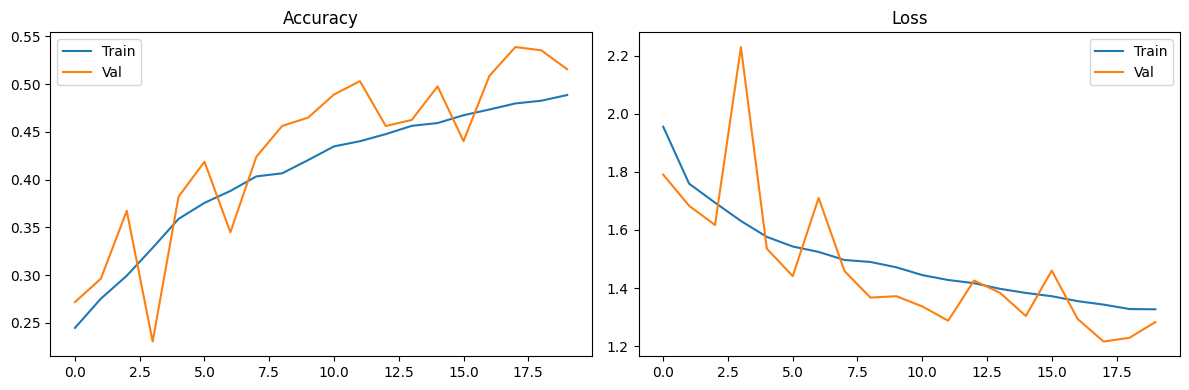

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].legend()
axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


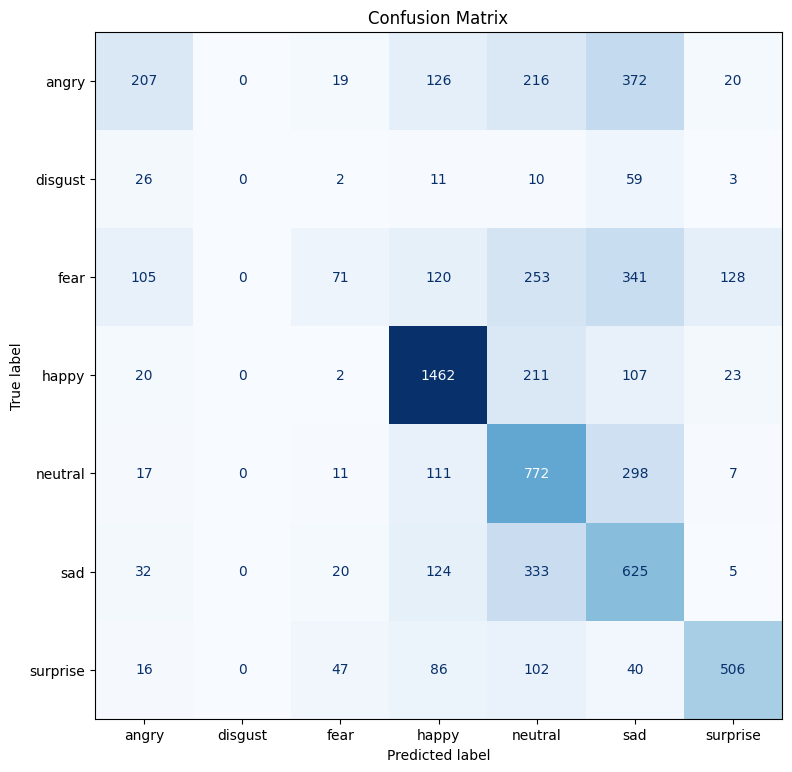

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ypred = model.predict(xtest)
cm = confusion_matrix(ytest_raw, le.inverse_transform(np.argmax(ypred, axis=1)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()